In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv("House_price.csv")

In [3]:
data.head()

,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4548 entries, 0 to 4547
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Avg. Area Income    4548 non-null   float64
 1   House Age           4548 non-null   float64
 2   Number of Rooms     4548 non-null   float64
 3   Number of Bedrooms  4548 non-null   float64
 4   Area Population     4548 non-null   float64
 5   Price               4548 non-null   float64
 6   Address             4548 non-null   object 
dtypes: float64(6), object(1)
memory usage: 248.8+ KB


In [5]:
data.duplicated(keep=False).value_counts()  #means no duplicate exists

False    4548
Name: count, dtype: int64

In [6]:
data["Number of Rooms"]=data["Number of Rooms"].round(0).astype(int)
data["Number of Bedrooms"]=data["Number of Bedrooms"].round(0).astype(int)
data["Area Population"]=data["Area Population"].round(0).astype(int)
data["House Age"]=data["House Age"].round(0).astype(int)

In [7]:
data["Area Population"].max()

69592

In [8]:
data.columns

Index(['Avg. Area Income', 'House Age', 'Number of Rooms',
       'Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [9]:
data.drop(["Address"], axis=1)

,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price
0,79545.45857,6,7,4,23087,1.059034e+06
1,79248.64245,6,7,3,40173,1.505891e+06
2,61287.06718,6,9,5,36882,1.058988e+06
3,63345.24005,7,6,3,34310,1.260617e+06
4,59982.19723,5,8,4,26354,6.309435e+05
...,...,...,...,...,...,...
4543,84556.63627,5,7,2,31797,1.326847e+06
4544,82732.98111,5,6,3,41137,1.252664e+06
4545,65694.05127,6,7,3,43407,1.359763e+06
4546,76061.35071,7,8,6,40877,1.778013e+06


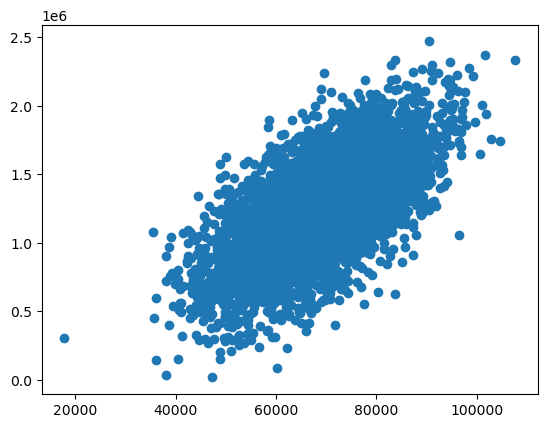

In [10]:
x=data["Avg. Area Income"]
y=data["Price"]

plt.scatter(x,y)


In [11]:
"""from scipy import stats
from sklearn.metrics import r2_score
a,b,r,p,std_err=stats.linregress(x,y)
def myfunc(x):
    return a*x+b
my_model=list(map(myfunc,x))

plt.scatter(x,y)
plt.plot(x,my_model)
print("a",a)
print("b",b)
print("p",p)
print("r",r)"""

'from scipy import stats\nfrom sklearn.metrics import r2_score\na,b,r,p,std_err=stats.linregress(x,y)\ndef myfunc(x):\n    return a*x+b\nmy_model=list(map(myfunc,x))\n\nplt.scatter(x,y)\nplt.plot(x,my_model)\nprint("a",a)\nprint("b",b)\nprint("p",p)\nprint("r",r)'

In [12]:
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1

In [39]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [40]:
df_cleaned = data[(data['Price'] >= lower_limit) & (data['Price'] <= upper_limit)]

In [41]:
print(f"Eski veri sayısı: {len(data)}")
print(f"Yeni veri sayısı: {len(df_cleaned)}")

Eski veri sayısı: 4548
Yeni veri sayısı: 4511


In [93]:
x = df_cleaned[['Avg. Area Income', 'House Age', 'Number of Rooms', 'Area Population']]
y= df_cleaned['Price']

In [94]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3, random_state=42)

In [95]:
x_train

,Avg. Area Income,House Age,Number of Rooms,Area Population
583,70673.84254,6,6,58256
4118,75144.86605,8,9,21261
2965,75892.50628,5,7,40909
3945,96899.01259,4,7,50293
4405,77089.65366,6,6,46741
...,...,...,...,...
4463,74401.69918,5,5,26015
471,62134.02206,7,7,32157
3122,70342.67105,5,7,34971
3804,61601.58059,5,6,17410


In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)

In [98]:
x_train

array([[ 0.1870435 ,  0.01536747, -0.95545979,  2.23887629],
       [ 0.61333129,  1.95597197,  1.93287716, -1.51433378],
       [ 0.68461473, -0.95493477,  0.00731919,  0.47899157],
       ...,
       [ 0.15546809, -0.95493477,  0.00731919, -0.12342933],
       [-0.67794738, -0.95493477, -0.95545979, -1.90502473],
       [-0.41358296,  1.95597197,  0.00731919, -1.31244465]],
      shape=(3157, 4))

In [99]:
import joblib 
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [100]:
x_test=scaler.fit_transform(x_test)

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def modelresults(predictions):
    print("Mean absolute error on model is {}".format(mean_absolute_error(y_test, predictions)))
    print("Root mean squared error on model is {}".format(np.sqrt(mean_squared_error(y_test, predictions))))

In [102]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [103]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
predictions_linear_regression=lr.predict(x_test)

In [106]:
modelresults(predictions_linear_regression)

Mean absolute error on model is 93429.3971500947
Root mean squared error on model is 117043.90175578347


In [107]:
data["Price"].mean()

np.float64(1233915.7950208222)

In [108]:
from sklearn.metrics import r2_score
print(f"R2 Score: {r2_score(y_test, predictions_linear_regression)}")

R2 Score: 0.8848801544888045


In [109]:
from sklearn.ensemble import RandomForestRegressor

In [110]:
rf_model = RandomForestRegressor(n_estimators=200,max_depth=10, random_state=42)

In [111]:
rf_model.fit(x_train, y_train.values.ravel())

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
rf_pred = rf_model.predict(x_test)

In [113]:
print(f"MAE: {mean_absolute_error(y_test, rf_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred))}")
print(f"R2 Score: {r2_score(y_test, rf_pred)}")

MAE: 102235.35408112202
RMSE: 128496.1947972091
R2 Score: 0.8612499494088854


In [114]:
coefficients = pd.DataFrame(lr.coef_, x.columns, columns=['Coefficents'])
print(coefficients.sort_values(by='Coefficents', ascending=False))

                    Coefficents
Avg. Area Income  225485.251473
House Age         156336.910008
Area Population   149653.838666
Number of Rooms   118932.157284


In [115]:
joblib.dump(lr,"model.pkl")
model=joblib.load

In [122]:
data["Avg. Area Income"].max()

107701.7484